In [1]:
import kagglehub
import zipfile
import pandas as pd
import numpy as np
import sklearn as sl
import tensorflow as tf
import keras as k
import matplotlib.pyplot as plt

In [2]:
#ml_env\Scripts\activate first run this 
#then jupyter lab

In [3]:
path = kagglehub.competition_download('titanic')


In [4]:
df_train = pd.read_csv('titanic/train.csv')

In [5]:
df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [6]:
df_train['Passenger_Type'] = df_train['Sex'] + df_train['Pclass'].astype(str)
df_train['Passenger_Type']

0        male3
1      female1
2      female3
3      female1
4        male3
        ...   
886      male2
887    female1
888    female3
889      male1
890      male3
Name: Passenger_Type, Length: 891, dtype: object

In [7]:
df_train['familySize'] = df_train['SibSp']+df_train['Parch']
df_train['familySize'] = pd.cut(df_train['familySize'], [-1,0,4,100],labels=["Alone", "Small Family", "Large Family"])
df_train['familySize']

0      Small Family
1      Small Family
2             Alone
3      Small Family
4             Alone
           ...     
886           Alone
887           Alone
888    Small Family
889           Alone
890           Alone
Name: familySize, Length: 891, dtype: category
Categories (3, object): ['Alone' < 'Small Family' < 'Large Family']

In [8]:
df_train['isAlone'] = df_train['familySize'] == 0
df_train['isAlone'].astype(int)

0      0
1      0
2      0
3      0
4      0
      ..
886    0
887    0
888    0
889    0
890    0
Name: isAlone, Length: 891, dtype: int64

In [9]:
df_train.dtypes

PassengerId          int64
Survived             int64
Pclass               int64
Name                object
Sex                 object
Age                float64
SibSp                int64
Parch                int64
Ticket              object
Fare               float64
Cabin               object
Embarked            object
Passenger_Type      object
familySize        category
isAlone               bool
dtype: object

In [10]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   PassengerId     891 non-null    int64   
 1   Survived        891 non-null    int64   
 2   Pclass          891 non-null    int64   
 3   Name            891 non-null    object  
 4   Sex             891 non-null    object  
 5   Age             714 non-null    float64 
 6   SibSp           891 non-null    int64   
 7   Parch           891 non-null    int64   
 8   Ticket          891 non-null    object  
 9   Fare            891 non-null    float64 
 10  Cabin           204 non-null    object  
 11  Embarked        889 non-null    object  
 12  Passenger_Type  891 non-null    object  
 13  familySize      891 non-null    category
 14  isAlone         891 non-null    bool    
dtypes: bool(1), category(1), float64(2), int64(5), object(6)
memory usage: 92.5+ KB


In [11]:
#Survived - target 
#rest are features 
#Drop passengerid, name, ticket

In [12]:
df_train = df_train.drop(columns=['PassengerId','Name','Ticket', 'Cabin'])

In [13]:
df_train

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Passenger_Type,familySize,isAlone
0,0,3,male,22.0,1,0,7.2500,S,male3,Small Family,False
1,1,1,female,38.0,1,0,71.2833,C,female1,Small Family,False
2,1,3,female,26.0,0,0,7.9250,S,female3,Alone,False
3,1,1,female,35.0,1,0,53.1000,S,female1,Small Family,False
4,0,3,male,35.0,0,0,8.0500,S,male3,Alone,False
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,male2,Alone,False
887,1,1,female,19.0,0,0,30.0000,S,female1,Alone,False
888,0,3,female,NaN,1,2,23.4500,S,female3,Small Family,False
889,1,1,male,26.0,0,0,30.0000,C,male1,Alone,False


In [14]:
df_train['Age'] = df_train['Age'].fillna(df_train['Age'].median()) #values are skewed with outliers, so median and its numeric columns
df_train['Fare'] = df_train['Fare'].fillna(df_train['Fare'].median()) #values are skewed with outliers and its numeric columns
df_train['Embarked'] = df_train['Embarked'].fillna(df_train['Embarked'].mode()[0])#mode fills row with most common label for string columns

In [15]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Survived        891 non-null    int64   
 1   Pclass          891 non-null    int64   
 2   Sex             891 non-null    object  
 3   Age             891 non-null    float64 
 4   SibSp           891 non-null    int64   
 5   Parch           891 non-null    int64   
 6   Fare            891 non-null    float64 
 7   Embarked        891 non-null    object  
 8   Passenger_Type  891 non-null    object  
 9   familySize      891 non-null    category
 10  isAlone         891 non-null    bool    
dtypes: bool(1), category(1), float64(2), int64(4), object(3)
memory usage: 64.6+ KB


In [16]:
 #convert_dtype() doesnt work here because ages are in form 34.5 so column remains float astype forces conversion to specified datatype even with float values rounds of decimal values  
df_train['Age'] = df_train['Age'].astype(int)

In [17]:
df_train

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Passenger_Type,familySize,isAlone
0,0,3,male,22,1,0,7.2500,S,male3,Small Family,False
1,1,1,female,38,1,0,71.2833,C,female1,Small Family,False
2,1,3,female,26,0,0,7.9250,S,female3,Alone,False
3,1,1,female,35,1,0,53.1000,S,female1,Small Family,False
4,0,3,male,35,0,0,8.0500,S,male3,Alone,False
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27,0,0,13.0000,S,male2,Alone,False
887,1,1,female,19,0,0,30.0000,S,female1,Alone,False
888,0,3,female,28,1,2,23.4500,S,female3,Small Family,False
889,1,1,male,26,0,0,30.0000,C,male1,Alone,False


In [18]:
df_train['ageCategory'] = pd.cut(df_train['Age'],[0,13,19,60,500],labels=['Child','Teen','Adult','Senior'])

In [19]:
df_train['ageCategory'].value_counts() #like a group by in SQL and count query groups into category and counts

ageCategory
Adult     705
Teen       93
Child      64
Senior     22
Name: count, dtype: int64

In [20]:
df_train.isna().sum()

Survived          0
Pclass            0
Sex               0
Age               0
SibSp             0
Parch             0
Fare              0
Embarked          0
Passenger_Type    0
familySize        0
isAlone           0
ageCategory       7
dtype: int64

In [21]:
df_train['ageCategory'] = df_train['ageCategory'].fillna(df_train['ageCategory'].mode()[0])

In [22]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Survived        891 non-null    int64   
 1   Pclass          891 non-null    int64   
 2   Sex             891 non-null    object  
 3   Age             891 non-null    int64   
 4   SibSp           891 non-null    int64   
 5   Parch           891 non-null    int64   
 6   Fare            891 non-null    float64 
 7   Embarked        891 non-null    object  
 8   Passenger_Type  891 non-null    object  
 9   familySize      891 non-null    category
 10  isAlone         891 non-null    bool    
 11  ageCategory     891 non-null    category
dtypes: bool(1), category(2), float64(1), int64(5), object(3)
memory usage: 65.7+ KB


In [23]:
#ML PREPROCESSING convert all columns to numeric format for easy processing by ML models / libs 

In [24]:
df_train = pd.get_dummies(df_train, columns=['Sex', 'Embarked','ageCategory','familySize','Passenger_Type'], sparse= False,dtype=int)

In [25]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 891 non-null    int64  
 1   Pclass                   891 non-null    int64  
 2   Age                      891 non-null    int64  
 3   SibSp                    891 non-null    int64  
 4   Parch                    891 non-null    int64  
 5   Fare                     891 non-null    float64
 6   isAlone                  891 non-null    bool   
 7   Sex_female               891 non-null    int64  
 8   Sex_male                 891 non-null    int64  
 9   Embarked_C               891 non-null    int64  
 10  Embarked_Q               891 non-null    int64  
 11  Embarked_S               891 non-null    int64  
 12  ageCategory_Child        891 non-null    int64  
 13  ageCategory_Teen         891 non-null    int64  
 14  ageCategory_Adult        8

In [26]:
df_train

,Survived,Pclass,Age,SibSp,Parch,Fare,isAlone,Sex_female,Sex_male,Embarked_C,...,ageCategory_Senior,familySize_Alone,familySize_Small Family,familySize_Large Family,Passenger_Type_female1,Passenger_Type_female2,Passenger_Type_female3,Passenger_Type_male1,Passenger_Type_male2,Passenger_Type_male3
0,0,3,22,1,0,7.2500,False,0,1,0,...,0,0,1,0,0,0,0,0,0,1
1,1,1,38,1,0,71.2833,False,1,0,1,...,0,0,1,0,1,0,0,0,0,0
2,1,3,26,0,0,7.9250,False,1,0,0,...,0,1,0,0,0,0,1,0,0,0
3,1,1,35,1,0,53.1000,False,1,0,0,...,0,0,1,0,1,0,0,0,0,0
4,0,3,35,0,0,8.0500,False,0,1,0,...,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27,0,0,13.0000,False,0,1,0,...,0,1,0,0,0,0,0,0,1,0
887,1,1,19,0,0,30.0000,False,1,0,0,...,0,1,0,0,1,0,0,0,0,0
888,0,3,28,1,2,23.4500,False,1,0,0,...,0,0,1,0,0,0,1,0,0,0
889,1,1,26,0,0,30.0000,False,0,1,1,...,0,1,0,0,0,0,0,1,0,0


In [27]:
X = df_train.loc[:,["Pclass","Age","SibSp","Parch","Fare","isAlone","Sex_female","Sex_male","Embarked_C","Embarked_Q","Embarked_S","ageCategory_Child","ageCategory_Teen","ageCategory_Adult","ageCategory_Senior","familySize_Alone", "familySize_Small Family", "familySize_Large Family", "Passenger_Type_female1",  "Passenger_Type_female2", "Passenger_Type_female3", "Passenger_Type_male1", "Passenger_Type_male2", "Passenger_Type_male3"]]
y = df_train['Survived']

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [29]:
from sklearn.preprocessing import StandardScaler #need to make quantities values balanced, not too much variations like 20 and 500 it will be 0.2 and 0.5
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #learn rules from training data and change/transform your training data 
X_test_scaled = scaler.transform(X_test) #transform/changes use the same rules from fit to testing data 


In [30]:
from sklearn.linear_model import LogisticRegression #cause its binary classification in 0 or 1 survived or not
survive = LogisticRegression()
survive.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [31]:
y_pred = survive.predict(X_test_scaled)

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_curve, roc_auc_score
score = accuracy_score(y_test, y_pred)

In [33]:
score 

0.8324022346368715

In [34]:
print(confusion_matrix(y_test, y_pred, labels=[0,1])) #false positive when model predicts true but it is false 
              #Model's prediction
              #No  yes 
#actually no  [92, 19]
#actually yes [19, 49]

[[103   8]
 [ 22  46]]


In [35]:
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))
#precision - How much data is predicted correctly
#recall - how many people actually survived 
#f1-score - balance score between precision and recall 
#support - how many real examples or train examples existed 
#accuracy - how often predictions are actually right 
#macro avg - both classes is treated with average 
#weighted avg - which group is bigger 

              precision    recall  f1-score   support

Not Survived       0.82      0.93      0.87       111
    Survived       0.85      0.68      0.75        68

    accuracy                           0.83       179
   macro avg       0.84      0.80      0.81       179
weighted avg       0.83      0.83      0.83       179



In [36]:
import sklearn.tree as tree
tree_classifier = tree.DecisionTreeClassifier(max_depth=9)
tree_classifier.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,9
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [37]:
tree_classifier.feature_importances_
#Pclass 	     Age 	    SibSp 	    Parch 	    Fare 	    Sex_female 	Sex_male Embarked_C    Embarked_Q 	Embarked_S
#0.09735601  0.14931776  0.07293018  0.02449683  0.20472959  0.43323786   0           0         0.00141754, 0.01651422
#Sex_female
#Fare
#Age
#Pclass

array([0.10146425, 0.19412505, 0.01653783, 0.01559756, 0.18330508,
       0.        , 0.        , 0.40775484, 0.        , 0.        ,
       0.0216357 , 0.        , 0.        , 0.        , 0.        ,
       0.00682826, 0.        , 0.0139669 , 0.        , 0.        ,
       0.        , 0.03878453, 0.        , 0.        ])

In [38]:
#Feature importance analysis showed that gender was the strongest predictor of survival, followed by fare, age, and passenger class. This suggests that social status, ticket value, and demographic factors played major roles in survival outcomes during the Titanic disaster. Embarkation location and family-related features had comparatively lower influence on model predictions.

In [39]:
y_pred = tree_classifier.predict(X_test_scaled)

In [40]:
tree_score = accuracy_score(y_test, y_pred)
tree_score

0.7932960893854749

In [41]:
print(confusion_matrix(y_test, y_pred))

[[101  10]
 [ 27  41]]


In [42]:
print(classification_report(y_test, y_pred, target_names=["Not Survived", "Survived"]))

              precision    recall  f1-score   support

Not Survived       0.79      0.91      0.85       111
    Survived       0.80      0.60      0.69        68

    accuracy                           0.79       179
   macro avg       0.80      0.76      0.77       179
weighted avg       0.79      0.79      0.79       179



<BarContainer object of 24 artists>

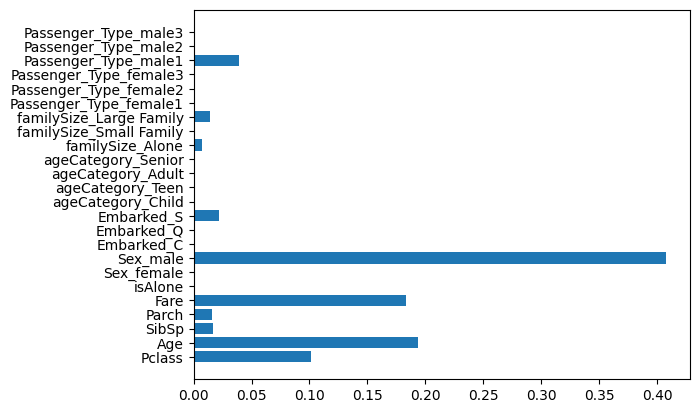

In [43]:
plt.barh(X.columns,tree_classifier.feature_importances_, data=tree_classifier.feature_importances_)

In [44]:
#The Decision Tree Classifier achieved better overall performance than Logistic Regression on the Titanic dataset. The Decision Tree produced a higher accuracy score of 81.56% compared to 77.09% for Logistic Regression, indicating stronger predictive capability.

#In terms of classification metrics, the Decision Tree also demonstrated improved precision, recall, and F1-score for the “Not Survived” class. While Logistic Regression achieved slightly higher recall for the “Survived” class (0.73 vs 0.66), the Decision Tree showed better overall balance and stronger weighted performance across both classes.

#This suggests that the Decision Tree was better able to capture complex and non-linear relationships among features such as passenger class, fare, age, and gender. However, increasing tree depth can increase the risk of overfitting, so further tuning and validation would still be necessary to optimize model generalization.

In [45]:
from sklearn.ensemble import RandomForestClassifier 
#model_optimisation for Randomforest
from sklearn.model_selection import cross_val_score, GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 9, 11],
}
random_forest = RandomForestClassifier() #n_estimators=300, max_depth=11
grid_results = GridSearchCV(random_forest, param_grid, cv=5) #this choose best params for n_estimator and max_depth
grid_results.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [5, 7, ...], 'n_estimators': [100, 200, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [46]:
y_pred = grid_results.predict(X_test)

In [47]:
print(accuracy_score(y_test, y_pred))

0.8212290502793296


In [48]:
print(confusion_matrix(y_test, y_pred))

[[99 12]
 [20 48]]


In [49]:
print(classification_report(y_test, y_pred, target_names=['Not Survived','Survived']))

              precision    recall  f1-score   support

Not Survived       0.83      0.89      0.86       111
    Survived       0.80      0.71      0.75        68

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



In [50]:
#Among all tested models, Random Forest Classifier achieved the best overall performance with an accuracy of approximately 85%. The model produced stronger precision, recall, and F1-scores compared to Logistic Regression and Decision Tree models, indicating better overall classification capability.

#The Random Forest performed well because it combined predictions from multiple decision trees, reducing overfitting and improving generalization. Feature patterns related to gender, fare, age, and passenger class were captured more effectively through ensemble learning.

#Overall, Random Forest proved to be the most reliable model for predicting Titanic passenger survival in this project.

In [51]:
scores = cross_val_score(random_forest, X, y, cv=5)
scores

array([0.79888268, 0.79775281, 0.84831461, 0.78089888, 0.83707865])

In [52]:
avg_score = scores.mean()
avg_score

np.float64(0.8125855250768941)

In [53]:
#understanding
#improving
#and preparing the model like a real ML workflow
grid_results.best_params_

{'max_depth': 9, 'n_estimators': 200}

In [54]:
grid_results.best_score_

np.float64(0.8201713779178569)

In [55]:
best_grid_result = grid_results.best_estimator_

In [56]:
import joblib #helps you saves your currently trained model so that the trained doesnt completely vanish
joblib.dump(best_grid_result,'random_forest_model.pkl')

['random_forest_model.pkl']

In [57]:
X.columns.tolist()

['Pclass',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'isAlone',
 'Sex_female',
 'Sex_male',
 'Embarked_C',
 'Embarked_Q',
 'Embarked_S',
 'ageCategory_Child',
 'ageCategory_Teen',
 'ageCategory_Adult',
 'ageCategory_Senior',
 'familySize_Alone',
 'familySize_Small Family',
 'familySize_Large Family',
 'Passenger_Type_female1',
 'Passenger_Type_female2',
 'Passenger_Type_female3',
 'Passenger_Type_male1',
 'Passenger_Type_male2',
 'Passenger_Type_male3']

In [58]:
joblib.dump(X.columns.tolist(), 'features.pkl')

['features.pkl']

In [59]:
X.columns.tolist()

['Pclass',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'isAlone',
 'Sex_female',
 'Sex_male',
 'Embarked_C',
 'Embarked_Q',
 'Embarked_S',
 'ageCategory_Child',
 'ageCategory_Teen',
 'ageCategory_Adult',
 'ageCategory_Senior',
 'familySize_Alone',
 'familySize_Small Family',
 'familySize_Large Family',
 'Passenger_Type_female1',
 'Passenger_Type_female2',
 'Passenger_Type_female3',
 'Passenger_Type_male1',
 'Passenger_Type_male2',
 'Passenger_Type_male3']

In [60]:
best_grid = joblib.load('random_forest_model.pkl') #load that currently trained model not matter when today tomorrow or after one year
best_grid.fit(X_train, y_train) #using that model 

,n_estimators,200
,criterion,'gini'
,max_depth,9
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [61]:
y_pred_best = best_grid.predict(X_test)
y_pred_best

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0])

In [62]:
print(accuracy_score(y_test, y_pred_best))

0.8156424581005587


In [63]:
print(confusion_matrix(y_test, y_pred_best))

[[99 12]
 [21 47]]


In [64]:
print(classification_report(y_test, y_pred, target_names=['Not Survived','Survived']))

              precision    recall  f1-score   support

Not Survived       0.83      0.89      0.86       111
    Survived       0.80      0.71      0.75        68

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



In [65]:
best_grid.feature_importances_

array([0.04782553, 0.14395314, 0.02874718, 0.02907093, 0.15976953,
       0.        , 0.12053763, 0.1091911 , 0.01609102, 0.00975227,
       0.01959671, 0.01885315, 0.00885033, 0.0128794 , 0.0058516 ,
       0.01269509, 0.01890169, 0.0132131 , 0.07165731, 0.03739981,
       0.02757569, 0.01337603, 0.01525719, 0.05895456])

<BarContainer object of 24 artists>

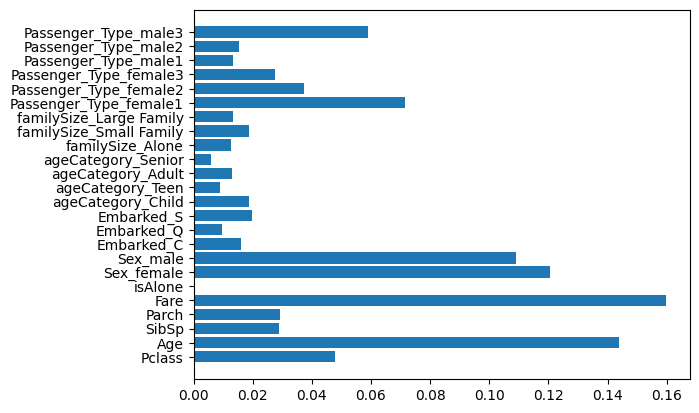

In [66]:
plt.barh(X.columns, best_grid.feature_importances_ , data=best_grid.feature_importances_)

In [67]:
y_score = best_grid.predict_proba(X_test) #like predict function

In [68]:
roc_curve(y_test , y_score[:, 1])

(array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.00900901, 0.00900901, 0.02702703, 0.02702703, 0.03603604,
        0.03603604, 0.03603604, 0.04504505, 0.04504505, 0.05405405,
        0.07207207, 0.07207207, 0.09009009, 0.09009009, 0.12612613,
        0.12612613, 0.12612613, 0.13513514, 0.13513514, 0.15315315,
        0.15315315, 0.16216216, 0.16216216, 0.18918919, 0.18918919,
        0.1981982 , 0.1981982 , 0.21621622, 0.21621622, 0.22522523,
        0.22522523, 0.28828829, 0.28828829, 0.43243243, 0.46846847,
        0.51351351, 0.52252252, 0.56756757, 0.56756757, 0.57657658,
        0.57657658, 0.59459459, 0.59459459, 0.61261261, 0.63063063,
        0.64864865, 0.67567568, 0.81081081, 0.81081081, 0.85585586,
        0.88288288, 0.96396396, 0.96396396, 0.98198198, 0.98198198,
        1.        , 1.        ]),
 array([0.        , 0.01470588, 0.04411765, 0.07352941, 0.26470588,
        0.26470588, 0.38235294, 0.38235294, 0.47058824, 0.47058824,
        0.5882

In [69]:
roc_auc_score(y_test , y_score[:, 1])

0.8642686804451511

In [70]:
#XGBOOST MODEL
import xgboost
xg = xgboost.XGBClassifier()
param_xg = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 9, 11],
}
xg_results = GridSearchCV(xg, param_xg, cv=5) #this choose best params for n_estimator and max_depth
xg_model = xg_results.fit(X_train, y_train)

In [71]:
best_xg_model = xg_model.best_estimator_
joblib.dump(best_xg_model,'best_xg_model.pkl')

['best_xg_model.pkl']

In [72]:
xg_best_model = joblib.load('best_xg_model.pkl')

In [73]:
y_pred = xg_best_model.predict(X_test)

In [74]:
print(accuracy_score(y_test, y_pred))

0.776536312849162


In [75]:
print(confusion_matrix(y_test, y_pred))

[[94 17]
 [23 45]]


In [76]:
print(classification_report(y_test, y_pred, target_names=['Not Survived','Survived']))

              precision    recall  f1-score   support

Not Survived       0.80      0.85      0.82       111
    Survived       0.73      0.66      0.69        68

    accuracy                           0.78       179
   macro avg       0.76      0.75      0.76       179
weighted avg       0.77      0.78      0.77       179



In [77]:
y_score = xg_model.predict_proba(X_test)

In [78]:
roc_curve(y_test, y_score[:,:1])

(array([0.        , 0.00900901, 0.15315315, 0.18018018, 0.18018018,
        0.21621622, 0.23423423, 0.26126126, 0.26126126, 0.27027027,
        0.27027027, 0.31531532, 0.31531532, 0.32432432, 0.32432432,
        0.40540541, 0.40540541, 0.41441441, 0.41441441, 0.55855856,
        0.56756757, 0.56756757, 0.58558559, 0.58558559, 0.69369369,
        0.72072072, 0.72072072, 0.72972973, 0.72972973, 0.74774775,
        0.74774775, 0.75675676, 0.75675676, 0.75675676, 0.77477477,
        0.77477477, 0.78378378, 0.8018018 , 0.8018018 , 0.83783784,
        0.83783784, 0.85585586, 0.85585586, 0.86486486, 0.86486486,
        0.9009009 , 0.91891892, 0.91891892, 0.92792793, 0.92792793,
        0.94594595, 0.94594595, 0.96396396, 0.96396396, 0.97297297,
        0.97297297, 0.99099099, 0.99099099, 1.        , 1.        ]),
 array([0.        , 0.        , 0.        , 0.        , 0.01470588,
        0.01470588, 0.01470588, 0.01470588, 0.04411765, 0.04411765,
        0.05882353, 0.05882353, 0.07352941, 0.

In [79]:
roc_auc_score(y_test, y_score[:,1])

0.8453232644409115

In [80]:
'''Several classification models were evaluated on the Titanic dataset, including Logistic Regression, Decision Tree, Random Forest, and XGBoost. Random Forest achieved the best overall performance with an ROC-AUC score of 0.852 and classification accuracy of 79%.

Additional feature engineering techniques were explored, including FamilySize, IsAlone, AgeCategory, FamilyType, and PassengerType. While these features provided additional insight into passenger characteristics, they did not improve model performance compared to the earlier Random Forest baseline, demonstrating that feature engineering must be validated through experimentation rather than assumed to improve results.

Based on evaluation metrics including accuracy, precision, recall, F1-score, and ROC-AUC, Random Forest was selected as the final model for the project.
'''

'Several classification models were evaluated on the Titanic dataset, including Logistic Regression, Decision Tree, Random Forest, and XGBoost. Random Forest achieved the best overall performance with an ROC-AUC score of 0.852 and classification accuracy of 79%.\n\nAdditional feature engineering techniques were explored, including FamilySize, IsAlone, AgeCategory, FamilyType, and PassengerType. While these features provided additional insight into passenger characteristics, they did not improve model performance compared to the earlier Random Forest baseline, demonstrating that feature engineering must be validated through experimentation rather than assumed to improve results.\n\nBased on evaluation metrics including accuracy, precision, recall, F1-score, and ROC-AUC, Random Forest was selected as the final model for the project.\n'

In [81]:
'''streamlit run .\streamlit_app.py --server.port 8502''' to run streamlit apps

SyntaxError: invalid syntax (2111025619.py, line 1)